In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [21]:
image_path = "../../data/output/cropped_image.jpg"
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

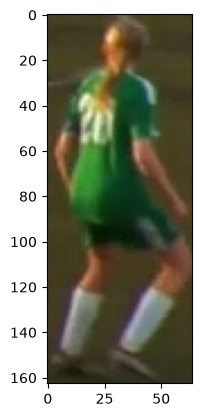

In [22]:
plt.imshow(image_rgb)
plt.show()

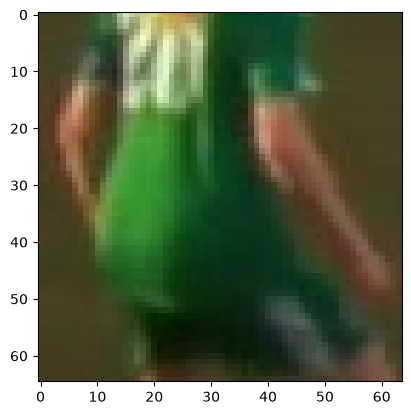

In [23]:
height, width = image_rgb.shape[:2]

top = int(height * 0.25)
bottom = int(height * 0.65)

top_half_image = image_rgb[top:bottom, :]
plt.imshow(top_half_image)
plt.show()

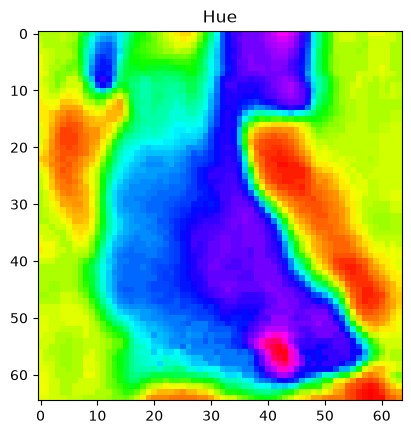

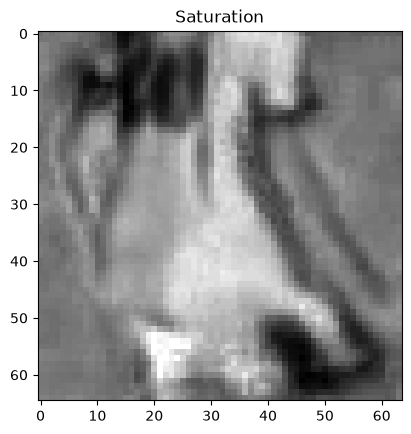

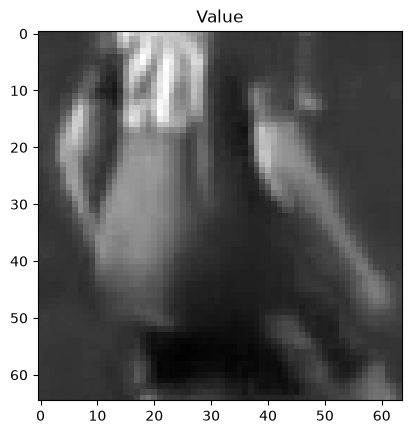

In [24]:
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)  # Convert BGR to HSV
jersey_hsv = image_hsv[top:bottom, :]  # Crop the top half of the image

hue = jersey_hsv[:, :, 0]
saturation = jersey_hsv[:, :, 1]
value = jersey_hsv[:, :, 2]

plt.imshow(hue, cmap="hsv")
plt.title("Hue")
plt.show()

plt.imshow(saturation, cmap="gray")
plt.title("Saturation")
plt.show()

plt.imshow(value, cmap="gray")
plt.title("Value")
plt.show()


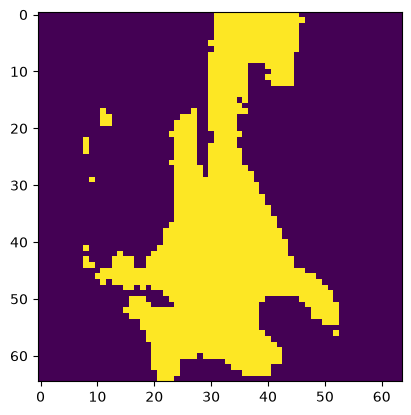

In [25]:
# Reshape the image into 2d array
image_2d = jersey_hsv.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(jersey_hsv.shape[0], jersey_hsv.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

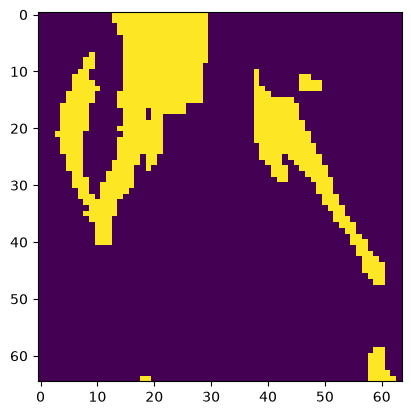

In [17]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [26]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [27]:
player_cluster = 1-non_player_cluster
print(player_cluster)

1


In [28]:
kmeans.cluster_centers_[player_cluster]

array([ 64.11666667, 196.52894737,  59.2254386 ])